# 투수 제구 성공 확률 — 팀 회의 요약

**회의용 / 2026-08-05 / 약 15분**

오늘 결정할 것은 세 가지입니다.

1. reverse·middle 보조 라벨 복원 모델을 계속 실험할지
2. 48차원 투수 임베딩을 팀 공통 피처로 채택할지
3. 공식 RandomForest 베이스라인을 기준으로 다음 모델 실험을 어떻게 나눌지

> 한 줄 결론: **임베딩 단독 모델은 아직 기준점 미달이지만, 누수 없는 OOF 임베딩과 2025 lookup은 팀 모델의 추가 피처로 바로 실험할 수 있다.**


## 1. 지금까지 확인한 사실

| 항목 | 결과 | 해석 |
|---|---:|---|
| 학습 행 | 1,475,092 | 투구 단위 |
| 세부 라벨 복원 가능 행 | 1,474,300 | 투수별 마지막 행 제외 |
| 성공 라벨 재구성 정확도 | 100% | reverse/middle 복원 검증용 |
| reverse 비율 | 22.90% | 포수 요구 반대 방향 |
| middle 비율 | 14.96% | 가운데 부근 |
| far residual 비율 | 13.17% | 두 경우가 아닌 실패 잔여 |
| Main↔Trackman 연결 투수 | 419명 | 보수적 임계값 적용 |
| 연결 투수의 Main 행 커버리지 | 86.30% | 미연결은 fallback |
| 다중 시즌 ID 연결 일치율 | 100% | 고신뢰 연결 내 기준 |

### 실패 구조

`reverse`는 다른 두 실패와 성격이 다르므로 첫 번째 조건부 head로 분리했습니다.

```text
P(success)
= (1 - P(reverse))
× (1 - P(middle | no reverse))
× (1 - P(far residual | no reverse, no middle))
```

`far residual`은 실제 공 위치로 직접 관측한 라벨이 아니라 공개된 세 실패 정의를 이용한 잔여 라벨입니다.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "outputs").exists():
    EXPERIMENT_DIR = NOTEBOOK_DIR
elif (NOTEBOOK_DIR / "experiment/pitcher_embedding/outputs").exists():
    EXPERIMENT_DIR = NOTEBOOK_DIR / "experiment/pitcher_embedding"
else:
    EXPERIMENT_DIR = (NOTEBOOK_DIR / "../..").resolve() / "experiment/pitcher_embedding"

OUTPUT_DIR = EXPERIMENT_DIR / "outputs"

quick = json.loads((OUTPUT_DIR / "submission_artifact_summary_quick.json").read_text(encoding="utf-8"))
full = json.loads((OUTPUT_DIR / "submission_artifact_summary_full.json").read_text(encoding="utf-8"))
crosswalk = pd.read_parquet(OUTPUT_DIR / "main_trackman_pitcher_crosswalk.parquet")
oof = pd.read_parquet(OUTPUT_DIR / "pitcher_season_embedding_oof.parquet")
lookup_2025 = pd.read_parquet(OUTPUT_DIR / "pitcher_embedding_lookup_2025.parquet")

print("산출물 로드 완료")


산출물 로드 완료


## 2. 신인·저표본 투수 처리

같은 시즌의 최종 투구 수가 100개 이하인지 여부는 시즌 중간에 알 수 없으므로 모델 입력에 사용하지 않습니다.

모델은 현재 행의 `asof_pitcher_n`과 이전 완료 시즌 Trackman 기록만 사용합니다.

| Cohort | 기준 |
|---|---|
| `UNSEEN` | 현재 메인 이력과 과거 Trackman 모두 없음 |
| `ROOKIE_1_25` | 확립 시즌 없음, 현재 1~25구 |
| `ROOKIE_26_100` | 확립 시즌 없음, 현재 26~100구 |
| `RETURNING` | 과거 100구 초과 시즌은 있으나 직전 시즌 기록 없음 |
| `VETERAN` | 그 외 |

개별 투수 임베딩 비중은 `α = n / (n + 100)`으로 조절해 저표본일수록 cohort 표현에 더 의존합니다.


## 3. 모델 결과 — 단독 제출은 아직 보류

평가 기준은 Brier Skill Score이며 높을수록 좋습니다. 운영진 베이스라인 기준은 **549.51**입니다.

,experiment,BSS
0,Direct head · quick,279.09
1,3-head · quick,363.23
2,3-head · full,313.58
3,LightGBM recent sanity,96.60
4,Official baseline threshold,549.51


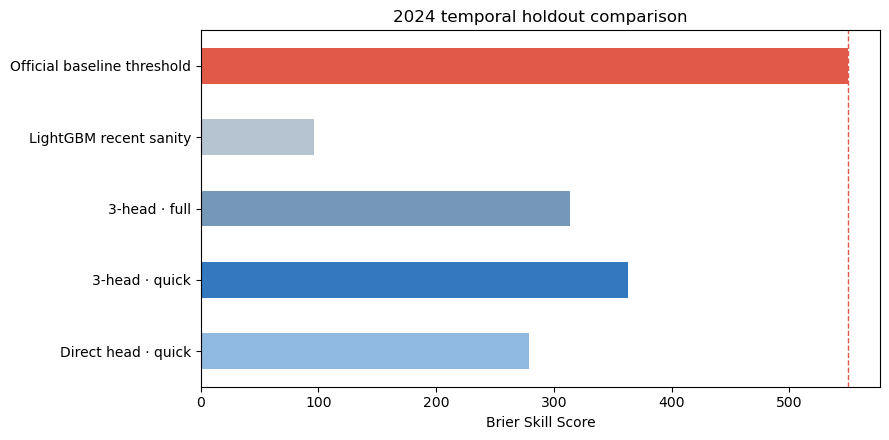

In [2]:
score_table = pd.DataFrame([
    {"experiment": "Direct head · quick", "BSS": 279.09},
    {"experiment": "3-head · quick", "BSS": quick["holdout"]["bss"]},
    {"experiment": "3-head · full", "BSS": full["holdout"]["bss"]},
    {"experiment": "LightGBM recent sanity", "BSS": 96.60},
    {"experiment": "Official baseline threshold", "BSS": 549.51},
])
display(score_table.style.format({"BSS": "{:.2f}"}))

colors = ["#8fb9e1", "#3478bf", "#7597b8", "#b6c4d1", "#e05a47"]
ax = score_table.plot.barh(x="experiment", y="BSS", figsize=(9, 4.5), color=colors, legend=False)
ax.set_xlabel("Brier Skill Score")
ax.set_ylabel("")
ax.set_title("2024 temporal holdout comparison")
ax.axvline(549.51, color="#e05a47", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


### 해석

- 빠른 3-head가 전체 학습보다 좋았습니다: `363.23 > 313.58`.
- 오래된 시즌을 모두 강하게 학습하면 최근 체제 변화에 과적합했습니다.
- 임베딩 모델은 공식 베이스라인을 대체하기보다 **추가 피처 또는 블렌딩 후보**로 사용합니다.
- 첫 리더보드 제출 기준축은 제공된 공식 `baseline_submit.zip`으로 유지합니다.


## 4. 팀에 공유할 피처 계약

48차원 구성은 모든 파일에서 동일합니다.

- 투수 ID 표현: 16차원
- 과거 Trackman tower: 24차원
- 신인/경험 cohort: 8차원


In [3]:
embedding_columns = [c for c in oof.columns if "_embedding_" in c]

feature_summary = pd.DataFrame([
    {
        "file": "pitcher_season_embedding_oof.parquet",
        "use": "2019~2024 학습 데이터",
        "key": "pitcher_id + season",
        "rows": len(oof),
        "embedding_dim": len(embedding_columns),
    },
    {
        "file": "pitcher_embedding_lookup_2025.parquet",
        "use": "2025 평가/추론",
        "key": "pitcher_id",
        "rows": len(lookup_2025),
        "embedding_dim": len([c for c in lookup_2025 if "_embedding_" in c]),
    },
])
display(feature_summary)

display(oof.groupby("season").agg(
    pitchers=("pitcher_id", "size"),
    oof_available=("oof_available", "mean"),
    known_before_season=("pitcher_known_before_season", "mean"),
).style.format({"oof_available": "{:.1%}", "known_before_season": "{:.1%}"}))


,file,use,key,rows,embedding_dim
0,pitcher_season_embedding_oof.parquet,2019~2024 학습 데이터,pitcher_id + season,2260,48
1,pitcher_embedding_lookup_2025.parquet,2025 평가/추론,pitcher_id,792,48


,pitchers,oof_available,known_before_season
season,,,
2019,355,0.0%,0.0%
2020,356,0.0%,0.0%
2021,386,100.0%,75.4%
2022,390,100.0%,77.4%
2023,382,100.0%,83.5%
2024,391,100.0%,79.3%


### 결합 예시

```python
# 학습: 반드시 시즌 순방향 OOF 사용
train = train.merge(
    pitcher_season_oof,
    on=["pitcher_id", "season"],
    how="left",
    validate="many_to_one",
)

# 추론: 2025 전용 lookup 사용
test = test.merge(
    pitcher_lookup_2025,
    on="pitcher_id",
    how="left",
    validate="many_to_one",
)
```

2019~2020 OOF는 0 벡터이며 `oof_available=False`입니다. 2025 lookup을 2019~2024 학습 행에 붙이면 supervised leakage이므로 금지합니다.


## 5. 오늘 회의에서 결정할 안건

### 결정 1 — 보조 라벨

- 운영진 답변 전까지 3-head 임베딩은 실험 피처로만 취급
- 불허 시 direct-success 또는 비지도 Trackman 임베딩으로 교체

### 결정 2 — 팀 공통 실험

아래 3개를 같은 시간 분할과 Brier Score로 비교합니다.

1. 공식 RF 베이스라인
2. 베이스라인 + OOF 48차원 임베딩
3. 최근 시즌 가중치 + OOF 임베딩

### 결정 3 — 검증 기준

- 랜덤 분할 금지
- 최근 시즌 홀드아웃 우선
- AUC가 아니라 Brier/BSS로 선택
- test 전체 집계·빈도·순서·보정 사용 금지

### 제안 담당 분배

| 작업 | 담당 |
|---|---|
| DACON 보조 라벨 문의 및 답변 공유 | 미정 |
| RF/CatBoost + OOF 임베딩 ablation | 미정 |
| Trackman crosswalk 임계값·미연결 fallback | 미정 |
| 제출 코드·시간·zip 구조 검증 | 미정 |
| 실험 결과 표 통합 및 최종 모델 결정 | 미정 |


## 6. 운영진 문의 문안

> **[DACON 답변 요청] train.csv 누적 asof 피처를 이용한 보조 라벨 생성 가능 여부**  
> 안녕하세요. 동일 투수의 다음 학습 행에 제공된 `asof_pitcher_reverse_rate` 및 `asof_pitcher_middle_rate`의 누적 변화량을 이용하여 현재 학습 행의 reverse/middle 보조 라벨을 복원하고, 이를 학습용 정답으로만 사용하는 것이 허용되는지 문의드립니다. 모델 입력에는 현재 행에서 투구 직전까지 확인 가능한 정보만 사용하며, 테스트 데이터의 다른 행·순서·분포·누적 통계는 일절 사용하지 않습니다. 해당 방식이 허용되지 않는다면 `control_success`만 직접 학습하는 모델을 사용하겠습니다.

관련 문서:

- [평가 기준](https://dacon.io/competitions/official/236743/overview/evaluation)
- [대회 규칙](https://dacon.io/competitions/official/236743/overview/rules)
- [코드 제출 가이드](https://cfiles.dacon.co.kr/competitions/236564/guide.html)


## 7. 회의 종료 시 남겨야 할 결론

- [ ] 보조 라벨 문의 담당자
- [ ] 공통 시간 분할과 평가 코드
- [ ] OOF 임베딩 사용 여부
- [ ] 각자 맡을 ablation 실험
- [ ] 첫 안전 제출과 실험 제출 순서
- [ ] 다음 결과 취합 시간

**권고안:** 공식 베이스라인을 먼저 복원하고, OOF 임베딩의 순수 증분만 확인한 뒤 채택 여부를 결정합니다.
